## 1. Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("train.csv")
df.head()


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Expense Type 1,Expense Type 2,Dependents,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,241.08,N,N,3.0,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,495.81,N,Y,1.0,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,171.95,N,Y,1.0,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,298.54,N,Y,2.0,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,491.41,N,Y,NaN,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


In [ ]:
df.shape


(30000, 24)

In [ ]:
df.isnull().sum()


Customer ID                       0
Name                              0
Gender                           53
Age                               0
Income (USD)                   4576
Income Stability               1683
Profession                        0
Type of Employment             7270
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)     172
Expense Type 1                    0
Expense Type 2                    0
Dependents                     2493
Credit Score                   1703
No. of Defaults                   0
Has Active Credit Card         1566
Property ID                       0
Property Age                   4850
Property Type                     0
Property Location               356
Co-Applicant                      0
Property Price                    0
Loan Sanction Amount (USD)      340
dtype: int64

## 2. Data Preprocessing

In [ ]:
df = df.drop(columns=['Customer ID', 'Name', 'Property ID'])
df.shape


(30000, 21)

In [ ]:
df = df.dropna(subset=['Loan Sanction Amount (USD)'])
df.shape


(29660, 21)

In [ ]:
num_cols = df.select_dtypes(include='number').columns.drop('Loan Sanction Amount (USD)')
cat_cols = df.select_dtypes(exclude='number').columns

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))


Numeric columns: 11
Categorical columns: 9


In [ ]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()


np.int64(0)

In [ ]:
df = pd.get_dummies(df, columns=list(cat_cols), drop_first=True)
df.shape


(29660, 46)

## 3. Exploratory Data Analysis

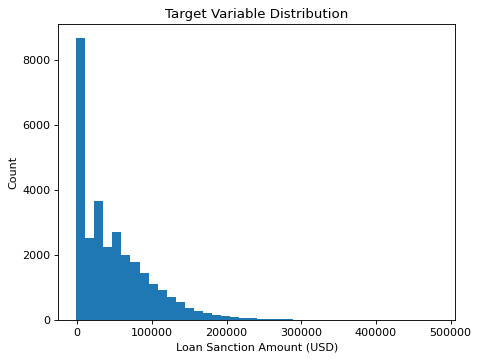

In [ ]:
plt.hist(df['Loan Sanction Amount (USD)'], bins=40)
plt.xlabel("Loan Sanction Amount (USD)")
plt.ylabel("Count")
plt.title("Target Variable Distribution")
plt.show()


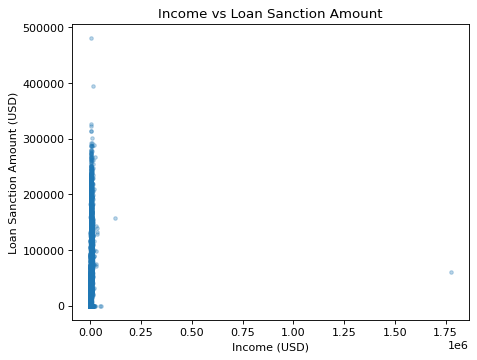

In [ ]:
plt.scatter(df['Income (USD)'], df['Loan Sanction Amount (USD)'], alpha=0.3, s=10)
plt.xlabel("Income (USD)")
plt.ylabel("Loan Sanction Amount (USD)")
plt.title("Income vs Loan Sanction Amount")
plt.show()


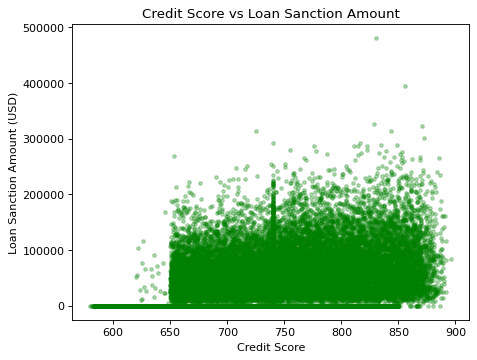

In [ ]:
plt.scatter(df['Credit Score'], df['Loan Sanction Amount (USD)'], alpha=0.3, s=10, color='green')
plt.xlabel("Credit Score")
plt.ylabel("Loan Sanction Amount (USD)")
plt.title("Credit Score vs Loan Sanction Amount")
plt.show()


## 4. Train-Test Split and Feature Scaling

In [ ]:
X = df.drop(columns=['Loan Sanction Amount (USD)'])
y = df['Loan Sanction Amount (USD)']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 23728
Test size: 5932


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling done")


Feature scaling done


## 5. Baseline Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

start = time.time()
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
lin_train_time = time.time() - start

y_pred_lin = lin_reg.predict(X_test_scaled)
print("Training done in", round(lin_train_time, 3), "sec")


Training done in 0.087 sec


In [ ]:
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

lin_metrics = get_metrics(y_test, y_pred_lin)
lin_metrics


{'MAE': 21592.263910365582, 'MSE': 1019014476.8076901, 'RMSE': np.float64(31922.00615261657), 'R2': 0.5510503567817138}

## 6. Ridge, Lasso and Elastic Net with Hyperparameter Tuning

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_grid = GridSearchCV(Ridge(), {'alpha': [0.01, 0.1, 1, 10, 100]}, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

print("Best alpha:", ridge_grid.best_params_['alpha'])
print("Best CV R2:", round(ridge_grid.best_score_, 3))


Best alpha: 100
Best CV R2: 0.574


In [ ]:
from sklearn.linear_model import Lasso

lasso_grid = GridSearchCV(Lasso(max_iter=10000, tol=1e-3), {'alpha': [0.001, 0.01, 0.1, 1, 10]}, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)

print("Best alpha:", lasso_grid.best_params_['alpha'])
print("Best CV R2:", round(lasso_grid.best_score_, 3))


Best alpha: 10
Best CV R2: 0.57


In [ ]:
from sklearn.linear_model import ElasticNet

en_param_grid = {'alpha': [0.01, 0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8]}
en_grid = GridSearchCV(ElasticNet(max_iter=10000, tol=1e-3), en_param_grid, cv=5, scoring='r2')
en_grid.fit(X_train_scaled, y_train)

print("Best params:", en_grid.best_params_)
print("Best CV R2:", round(en_grid.best_score_, 3))


Best params: {'alpha': 0.1, 'l1_ratio': 0.5}
Best CV R2: 0.584


In [ ]:
tuning_summary = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'Best Parameters': [ridge_grid.best_params_, lasso_grid.best_params_, en_grid.best_params_],
    'Best CV R2': [round(ridge_grid.best_score_,3), round(lasso_grid.best_score_,3), round(en_grid.best_score_,3)]
})

tuning_summary


,Model,Best Parameters,Best CV R2
0,Ridge,{'alpha': 100},0.574
1,Lasso,{'alpha': 10},0.570
2,Elastic Net,"{'alpha': 0.1, 'l1_ratio': 0.5}",0.584


## 7. Train Final Models with Best Parameters

In [ ]:
ridge = Ridge(alpha=ridge_grid.best_params_['alpha'])
start = time.time()
ridge.fit(X_train_scaled, y_train)
ridge_train_time = time.time() - start
y_pred_ridge = ridge.predict(X_test_scaled)
ridge_metrics = get_metrics(y_test, y_pred_ridge)
ridge_metrics


{'MAE': 21589.230944685667, 'MSE': 1017776098.5688441, 'RMSE': np.float64(31902.6033196171), 'R2': 0.5515959520417938}

In [ ]:
lasso = Lasso(alpha=lasso_grid.best_params_['alpha'], max_iter=10000, tol=1e-3)
start = time.time()
lasso.fit(X_train_scaled, y_train)
lasso_train_time = time.time() - start
y_pred_lasso = lasso.predict(X_test_scaled)
lasso_metrics = get_metrics(y_test, y_pred_lasso)
lasso_metrics


{'MAE': 21569.423500051802, 'MSE': 1018436600.6475444, 'RMSE': np.float64(31912.95349301823), 'R2': 0.5513049530625581}

In [ ]:
elastic = ElasticNet(alpha=en_grid.best_params_['alpha'], l1_ratio=en_grid.best_params_['l1_ratio'], max_iter=10000, tol=1e-3)
start = time.time()
elastic.fit(X_train_scaled, y_train)
elastic_train_time = time.time() - start
y_pred_elastic = elastic.predict(X_test_scaled)
elastic_metrics = get_metrics(y_test, y_pred_elastic)
elastic_metrics


{'MAE': 21755.24386498963, 'MSE': 1019351983.9062318, 'RMSE': np.float64(31927.292148038985), 'R2': 0.5509016604727579}

## 8. Cross-Validation Performance (K=5)

In [ ]:
from sklearn.model_selection import cross_validate

scoring = {'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'R2': 'r2'}
models = {'Linear': lin_reg, 'Ridge': ridge, 'Lasso': lasso, 'Elastic Net': elastic}

cv_rows = []
for name, model in models.items():
    cv_res = cross_validate(model, X_train_scaled, y_train, cv=5, scoring=scoring)
    mae = -cv_res['test_MAE'].mean()
    mse = -cv_res['test_MSE'].mean()
    rmse = np.sqrt(mse)
    r2 = cv_res['test_R2'].mean()
    cv_rows.append([name, mae, mse, rmse, r2])

cv_table = pd.DataFrame(cv_rows, columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2']).round(3)
cv_table


,Model,MAE,MSE,RMSE,R2
0,Linear,21549.688,1.011127e+09,31798.226,0.568
1,Ridge,21566.836,9.960923e+08,31560.930,0.574
2,Lasso,21543.656,1.005335e+09,31707.011,0.570
3,Elastic Net,21743.082,9.726963e+08,31188.079,0.584


## 9. Test Set Performance

In [ ]:





test_table = pd.DataFrame({
    'Linear': lin_metrics, 'Ridge': ridge_metrics, 'Lasso': lasso_metrics, 'Elastic Net': elastic_metrics
}).T.round(3)

test_table


,MAE,MSE,RMSE,R2
Linear,21592.264,1.019014e+09,31922.006,0.551
Ridge,21589.231,1.017776e+09,31902.603,0.552
Lasso,21569.424,1.018437e+09,31912.953,0.551
Elastic Net,21755.244,1.019352e+09,31927.292,0.551


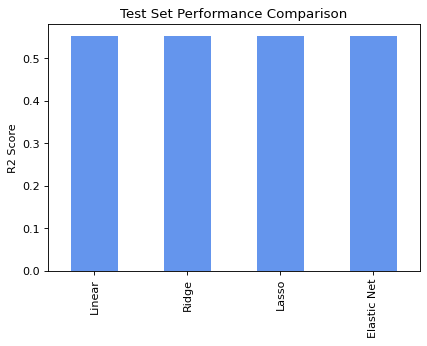

In [ ]:
test_table['R2'].plot(kind='bar', color='cornflowerblue', figsize=(6,4))
plt.ylabel("R2 Score")
plt.title("Test Set Performance Comparison")
plt.show()


## 10. Effect of Regularization on Coefficients

In [ ]:
top_features = ['Income (USD)', 'Credit Score', 'Loan Amount Request (USD)']
feature_idx = [list(X.columns).index(f) for f in top_features]

coef_table = pd.DataFrame({
    'Linear': lin_reg.coef_[feature_idx],
    'Ridge': ridge.coef_[feature_idx],
    'Lasso': lasso.coef_[feature_idx],
    'Elastic Net': elastic.coef_[feature_idx]
}, index=top_features).round(2)

coef_table


,Linear,Ridge,Lasso,Elastic Net
Income (USD),47113.76,1025.55,735.44,92.60
Credit Score,11635.13,11604.40,11637.10,11224.93
Loan Amount Request (USD),35371.37,33829.08,35171.96,25147.04


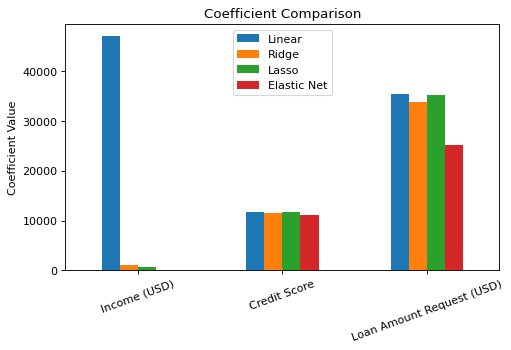

In [ ]:
coef_table.plot(kind='bar', figsize=(7,4))
plt.ylabel("Coefficient Value")
plt.title("Coefficient Comparison")
plt.xticks(rotation=20)
plt.show()


## 11. Predicted vs Actual and Residual Plots

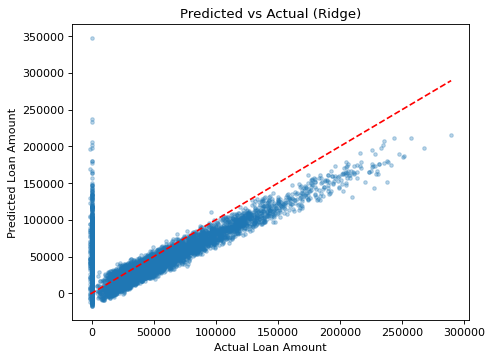

In [ ]:
plt.scatter(y_test, y_pred_ridge, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Predicted vs Actual (Ridge)")
plt.show()


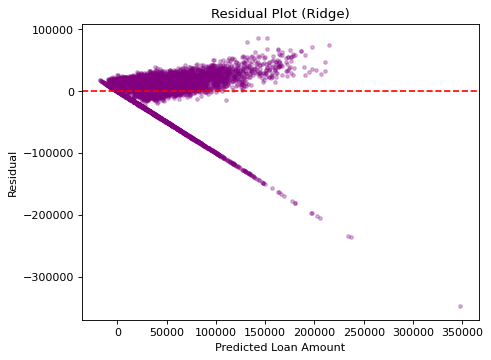

In [ ]:
residuals = y_test - y_pred_ridge

plt.scatter(y_pred_ridge, residuals, alpha=0.3, s=10, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Loan Amount")
plt.ylabel("Residual")
plt.title("Residual Plot (Ridge)")
plt.show()


## 12. Training Error vs Validation Error (Effect of Regularization Strength)

In [ ]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_errors = []
val_errors = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    train_pred = model.predict(X_train_scaled)
    train_mse = mean_squared_error(y_train, train_pred)

    cv_scores = cross_validate(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    val_mse = -cv_scores['test_score'].mean()

    train_errors.append(train_mse)
    val_errors.append(val_mse)

print("Errors computed for all alpha values")


Errors computed for all alpha values


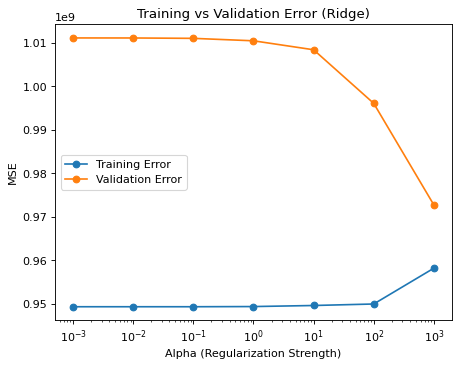

In [ ]:
plt.plot(alphas, train_errors, marker='o', label='Training Error')
plt.plot(alphas, val_errors, marker='o', label='Validation Error')
plt.xscale('log')
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("MSE")
plt.title("Training vs Validation Error (Ridge)")
plt.legend()
plt.show()
